In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from id import (
    build_hankel,
    collect_autocorrelations,
    collect_markov_parameters,
    collect_time_series,
    cva_initial_estimate,
    em_refine,
    era,
    estimate_noise_covariances,
    make_id_figure,
)
from pgf_utils import (
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)

In [2]:
# ── experiment constants ───────────────────────────────────────────────────────
RANDOM_SEED = 0        # brain seed for ERA Markov parameter collection
NOISE_SEED  = 1        # brain seed for ERA noise covariance estimation
CVA_SEED    = 2        # brain seed for CVA+EM time series
DRIVE_SEED  = 42       # RNG seed for CVA+EM random drive

# ERA parameters
N_HANKEL_ROWS = 20
N_HANKEL_COLS = 30
N_MARKOV      = N_HANKEL_ROWS + N_HANKEL_COLS + 5   # 55 Markov parameters
N_NOISE_LAGS  = 30

# Shared: both ERA noise estimation and CVA+EM time series use N_SAMPLES steps
N_SAMPLES = 5000
N_BURNIN  = 500

# CVA+EM parameters
HORIZON     = 30
MAX_EM_ITER = 200
EM_TOL      = 1e-6

MODEL_ORDER_PATH = Path("../../data/model_order.npz")
ERA_PATH         = Path("../../data/era_matrices.npz")
CVA_EM_PATH      = Path("../../data/cva_em_matrices.npz")
FIGURES_PATH     = Path("../../figures")
CAPTIONS_PATH    = Path("../../captions")

NOTEBOOK_GITHUB_URL = (
    "https://github.com/tahmidazam/gg4/blob/main/notebooks/id/id.ipynb"
)

In [3]:
# ── derived: Brain dimensions and model order ──────────────────────────────────
_b = Brain(random_seed=RANDOM_SEED)
P_DIM = _b.input_dim
Q_DIM = len(_b.measure())
del _b

LATENT_DIM = int(np.load(MODEL_ORDER_PATH)["n_latent"])  # shared by both methods

print(f"p (inputs)                 = {P_DIM}")
print(f"q (outputs)                = {Q_DIM}")
print(f"n (latent dim / order)     = {LATENT_DIM}  [from {MODEL_ORDER_PATH}]")
print(f"N_SAMPLES (both methods)   = {N_SAMPLES}")

p (inputs)                 = 2
q (outputs)                = 16
n (latent dim / order)     = 6  [from ../../data/model_order.npz]
N_SAMPLES (both methods)   = 5000


In [4]:
# ── ERA: collect Markov parameters, run ERA, estimate Q and R ──────────────────
markov = collect_markov_parameters(RANDOM_SEED, P_DIM, N_MARKOV)
H0, H1 = build_hankel(markov, N_HANKEL_ROWS, N_HANKEL_COLS)
A_era, B_era, C_era, _ = era(H0, H1, LATENT_DIM, Q_DIM, P_DIM)

autocorrs = collect_autocorrelations(NOISE_SEED, N_SAMPLES, N_NOISE_LAGS, N_BURNIN)
Q_era, R_era = estimate_noise_covariances(A_era, C_era, autocorrs)

print(f"ERA   A: {A_era.shape},  spectral radius = {np.max(np.abs(np.linalg.eigvals(A_era))):.4f}")
print(f"ERA   B: {B_era.shape}")
print(f"ERA   C: {C_era.shape}")
print(f"ERA   Q min eigval: {np.linalg.eigvalsh(Q_era).min():.2e}")
print(f"ERA   R min eigval: {np.linalg.eigvalsh(R_era).min():.2e}")

Impulse responses:   0%|          | 0/2 [00:00<?, ?it/s]

Noise statistics:   0%|          | 0/5000 [00:00<?, ?it/s]

ERA   A: (6, 6),  spectral radius = 0.9661
ERA   B: (6, 2)
ERA   C: (16, 6)
ERA   Q min eigval: -6.71e-14
ERA   R min eigval: -5.11e-16


In [5]:
# ── CVA+EM: collect time series, run CVA initialisation, refine with EM ────────
measurement, drive = collect_time_series(CVA_SEED, N_SAMPLES, N_BURNIN, DRIVE_SEED)

# Centre both channels: the LGSSM has no bias term, so a fixed DC offset in
# y must be removed; centring u as well keeps the model fitting fluctuations
# to fluctuations so that the per-channel gains in B are correctly separated.
y_centred = measurement - measurement.mean(axis=0)
u_centred = drive - drive.mean(axis=0)

A0, B0, C0, Q0, R0, _ = cva_initial_estimate(y_centred, u_centred, LATENT_DIM, HORIZON)
A_cva, B_cva, C_cva, Q_cva, R_cva, mu0, P0, logliks = em_refine(
    y_centred, u_centred, A0, B0, C0, Q0, R0, LATENT_DIM, MAX_EM_ITER, EM_TOL
)

print(f"CVA+EM A: {A_cva.shape},  spectral radius = {np.max(np.abs(np.linalg.eigvals(A_cva))):.4f}")
print(f"CVA+EM B: {B_cva.shape}")
print(f"CVA+EM C: {C_cva.shape}")
print(f"CVA+EM Q min eigval: {np.linalg.eigvalsh(Q_cva).min():.2e}")
print(f"CVA+EM R min eigval: {np.linalg.eigvalsh(R_cva).min():.2e}")
print(f"EM converged in {len(logliks)} iterations")

EM refinement:   0%|          | 0/200 [00:00<?, ?iter/s]

CVA+EM A: (6, 6),  spectral radius = 0.9408
CVA+EM B: (6, 2)
CVA+EM C: (16, 6)
CVA+EM Q min eigval: 4.46e-02
CVA+EM R min eigval: 5.09e-01
EM converged in 57 iterations


In [6]:
# ── save identified matrices ───────────────────────────────────────────────────
ERA_PATH.parent.mkdir(parents=True, exist_ok=True)
np.savez(ERA_PATH, A=A_era, B=B_era, C=C_era, Q=Q_era, R=R_era)
print(f"ERA    matrices saved to {ERA_PATH.resolve()}")

np.savez(CVA_EM_PATH, A=A_cva, B=B_cva, C=C_cva, Q=Q_cva, R=R_cva)
print(f"CVA+EM matrices saved to {CVA_EM_PATH.resolve()}")

ERA    matrices saved to /Users/tahmidazam/Developer/gg4/data/era_matrices.npz
CVA+EM matrices saved to /Users/tahmidazam/Developer/gg4/data/cva_em_matrices.npz


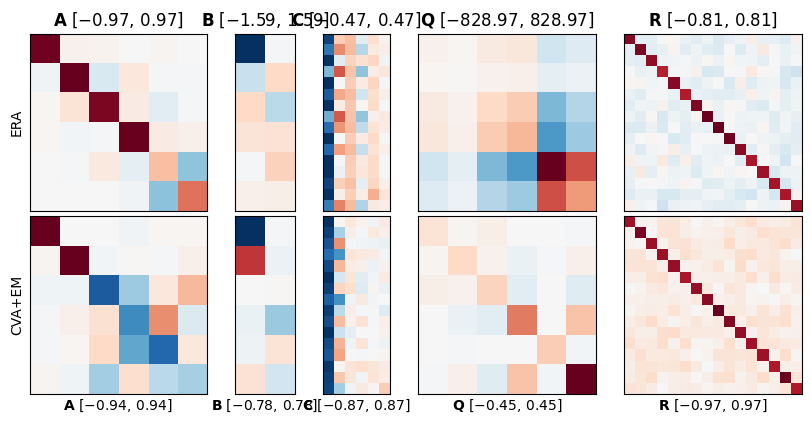

In [7]:
# ── figure: 2-row heatmap comparison ──────────────────────────────────────────
ERA_MATS = [A_era, B_era, C_era, Q_era, R_era]
CVA_MATS = [A_cva, B_cva, C_cva, Q_cva, R_cva]

configure_screen()
fig = make_id_figure(ERA_MATS, CVA_MATS, LATENT_DIM, P_DIM, Q_DIM, figsize=(8, 4))
plt.show()

In [8]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 1.0   # fraction of A4 content width
FIG_HEIGHT_FRAC = 0.22  # fraction of A4 content height

configure_pgf()
fig = make_id_figure(
    ERA_MATS, CVA_MATS, LATENT_DIM, P_DIM, Q_DIM,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "id.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/id.pgf


In [9]:
# ── caption ────────────────────────────────────────────────────────────────────
caption = (
    r"ERA (top row) and CVA+EM (bottom row) estimates of system matrices. "
    r"Red indicates positive, blue negative; each subplot title shows the symmetric colour range."
)
save_caption(CAPTIONS_PATH / "id.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/id.tex
ERA (top row) and CVA+EM (bottom row) estimates of system matrices. Red indicates positive, blue negative; each subplot title shows the symmetric colour range.
